---
# 1. Setup & Data Ingestion


In [142]:
# ── Install dependencies ──
# Uncomment the line below if running in Google Colab
# !pip install xgboost lightgbm mlflow shap imbalanced-learn fastapi uvicorn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


In [143]:
%pip install -q imbalanced-learn
%pip install -q xgboost
%pip install -q lightgbm
%pip install -q mlflow
%pip install -q shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/o

### 1.1 Load the Dataset

We use the IBM Telco Customer Churn dataset from Kaggle.

**To get the data:**
1. Download from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
2. Upload `WA_Fn-UseC_-Telco-Customer-Churn.csv` to your working directory (or Colab files panel)

Alternatively, uncomment the Kaggle API cell below.


In [144]:
# ── Option A: Kaggle API download (uncomment if you have kaggle.json configured) ──
# !kaggle datasets download -d blastchar/telco-customer-churn --unzip

# ── Option B: Direct load (upload the CSV first) ──
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn 2.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Dataset shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.2 Schema Validation

> **⚠️ Production rule:** Never trust incoming data. Always validate schema, dtypes, and expected ranges before any processing. A silent dtype error will propagate through your entire pipeline.


In [145]:
# ── Schema validation ──
expected_columns = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'
]

# Check all expected columns exist
missing_cols = set(expected_columns) - set(df.columns)
extra_cols = set(df.columns) - set(expected_columns)
print(f"Missing columns: {missing_cols or 'None ✓'}")
print(f"Extra columns:   {extra_cols or 'None ✓'}")

# Check dtypes — this is where you catch the TotalCharges bug
print(f"\nData types:\n{df.dtypes}")


Missing columns: None ✓
Extra columns:   None ✓

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


### 1.3 The `TotalCharges` Trap

> **🎓 Instructor Note:** This is one of the best teaching moments in this dataset. `TotalCharges` *looks* numeric but Pandas reads it as `object` because 11 rows contain whitespace `' '` instead of a number. These are brand-new customers with `tenure=0`. If students don't catch this, their scaler will either crash or silently drop rows.


In [146]:
# ── Catch the TotalCharges bug ──
print(f"TotalCharges dtype BEFORE fix: {df['TotalCharges'].dtype}")

# Find the problematic rows
bad_rows = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]
print(f"\nProblematic rows ({len(bad_rows)}):")
print(bad_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].to_string())

# Fix: coerce to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nTotalCharges dtype AFTER fix: {df['TotalCharges'].dtype}")
print(f"Null values in TotalCharges: {df['TotalCharges'].isna().sum()}")

# Fill nulls for tenure=0 customers — their total charges should be 0
df['TotalCharges'].fillna(0, inplace=True)
print(f"Null values after fill: {df['TotalCharges'].isna().sum()} ✓")


TotalCharges dtype BEFORE fix: str

Problematic rows (11):
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             

TotalCharges dtype AFTER fix: float64
Null values in TotalCharges: 11
Null values after fill: 11 ✓


In [147]:
# ── Basic data quality summary ──
print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)
print(f"\nRows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nNull values per column:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "  None ✓")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nTarget distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {(df['Churn'] == 'Yes').mean():.1%}")


DATA QUALITY REPORT

Rows: 7,043
Columns: 21

Null values per column:
TotalCharges    11
dtype: int64

Duplicate rows: 0

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


---
# 2. Exploratory Data Analysis

> **🎓 Instructor Note:** EDA is not optional "nice-to-have" — it's where you discover the features that matter, the data leakage risks, and the class imbalance strategy. Students who skip EDA build worse models. Period.


### 2.1 Target Variable: Class Imbalance

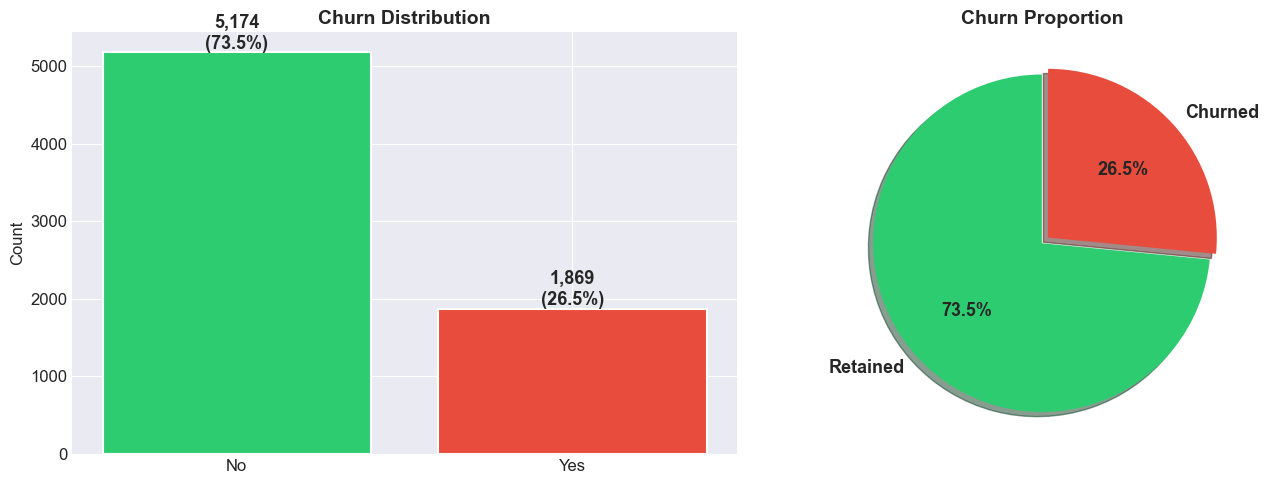


⚠️  Imbalance ratio: 2.8:1
   A dummy classifier predicting 'No' for everyone gets 73.5% accuracy.
   This is why accuracy is a MISLEADING metric for this problem.


In [148]:
# ── Target distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (val, count) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, count + 50, f"{count:,}\n({count/len(df):.1%})", ha='center', fontweight='bold', fontsize=13)
axes[0].set_title("Churn Distribution", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13, 'fontweight': 'bold'},
            explode=(0, 0.05), shadow=True)
axes[1].set_title("Churn Proportion", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️  Imbalance ratio: {churn_counts['No'] / churn_counts['Yes']:.1f}:1")
print("   A dummy classifier predicting 'No' for everyone gets 73.5% accuracy.")
print("   This is why accuracy is a MISLEADING metric for this problem.")


### 2.2 Churn by Contract Type

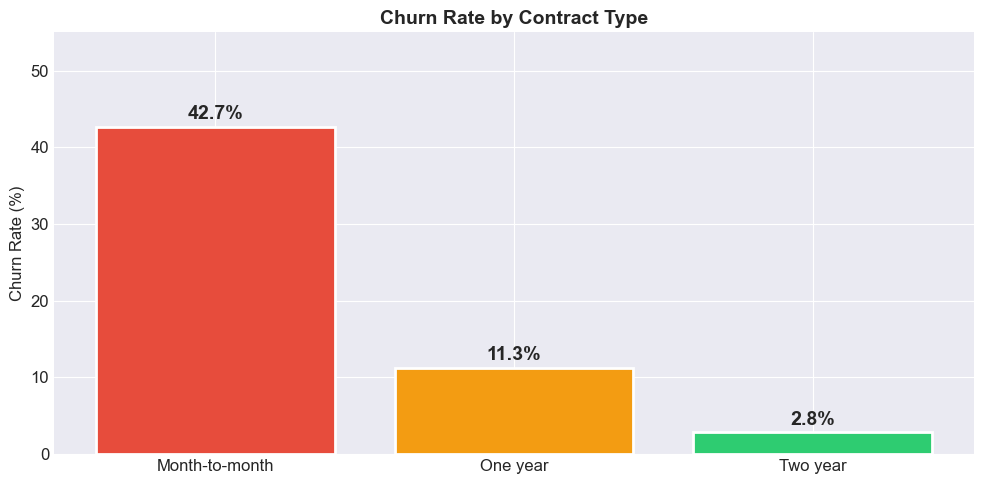


🔑 KEY INSIGHT: Month-to-month contracts have 15× the churn rate of two-year contracts.
   This will be the single most predictive feature in the model.


In [149]:
# ── Churn rate by contract type ──
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(contract_churn.index, contract_churn.values * 100,
              color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=2)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1%}", ha='center', fontweight='bold', fontsize=14)
ax.set_ylabel("Churn Rate (%)", fontsize=12)
ax.set_title("Churn Rate by Contract Type", fontsize=14, fontweight='bold')
ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

print("\n🔑 KEY INSIGHT: Month-to-month contracts have 15× the churn rate of two-year contracts.")
print("   This will be the single most predictive feature in the model.")


### 2.3 Churn by Tenure

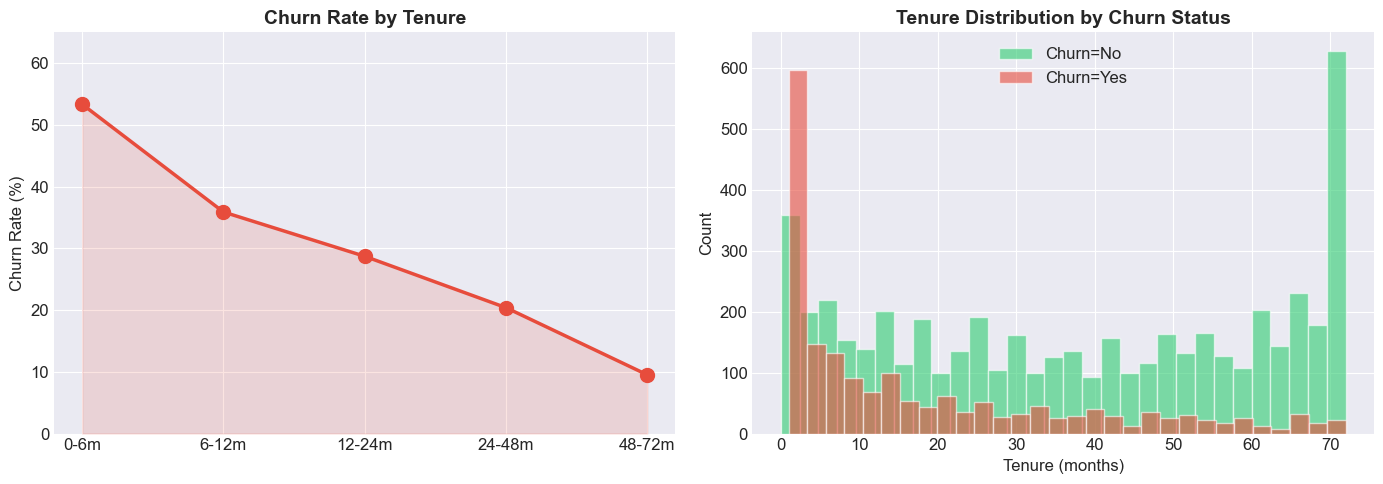


🔑 Nearly half of customers in their first 6 months leave.
   This justifies engineering an 'is_new_customer' flag.


In [150]:
# ── Churn rate by tenure buckets ──
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 48, 72],
                              labels=['0-6m', '6-12m', '12-24m', '24-48m', '48-72m'])

tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by tenure
axes[0].plot(tenure_churn.index.astype(str), tenure_churn.values * 100,
             'o-', color='#e74c3c', linewidth=2.5, markersize=10)
axes[0].fill_between(range(len(tenure_churn)), tenure_churn.values * 100,
                      alpha=0.15, color='#e74c3c')
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_title("Churn Rate by Tenure", fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 65)

# Tenure distribution by churn
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    subset = df[df['Churn'] == label]['tenure']
    axes[1].hist(subset, bins=30, alpha=0.6, label=f'Churn={label}', color=color, edgecolor='white')
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Count")
axes[1].set_title("Tenure Distribution by Churn Status", fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n🔑 Nearly half of customers in their first 6 months leave.")
print("   This justifies engineering an 'is_new_customer' flag.")


### 2.4 Monthly Charges & Services

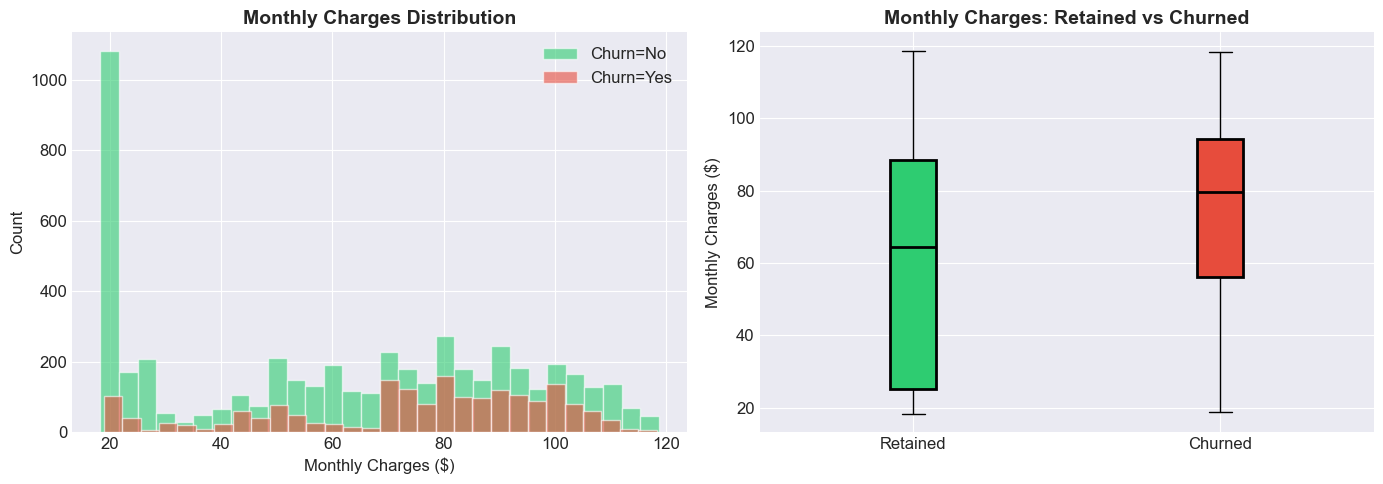


Avg Monthly Charges — Churned: $74 vs Retained: $61
🔑 Churners pay more on average — high-value customers are the most at-risk.


In [151]:
# ── Monthly charges distribution by churn ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    subset = df[df['Churn'] == label]['MonthlyCharges']
    axes[0].hist(subset, bins=30, alpha=0.6, label=f'Churn={label}', color=color, edgecolor='white')
axes[0].set_xlabel("Monthly Charges ($)")
axes[0].set_ylabel("Count")
axes[0].set_title("Monthly Charges Distribution", fontsize=14, fontweight='bold')
axes[0].legend()

# Boxplot comparison
churn_data = [df[df['Churn'] == 'No']['MonthlyCharges'],
              df[df['Churn'] == 'Yes']['MonthlyCharges']]
bp = axes[1].boxplot(churn_data, labels=['Retained', 'Churned'], patch_artist=True,
                     boxprops=dict(linewidth=2), medianprops=dict(linewidth=2, color='black'))
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_ylabel("Monthly Charges ($)")
axes[1].set_title("Monthly Charges: Retained vs Churned", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nAvg Monthly Charges — Churned: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.0f}"
      f" vs Retained: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.0f}")
print("🔑 Churners pay more on average — high-value customers are the most at-risk.")


### 2.5 Correlation Analysis

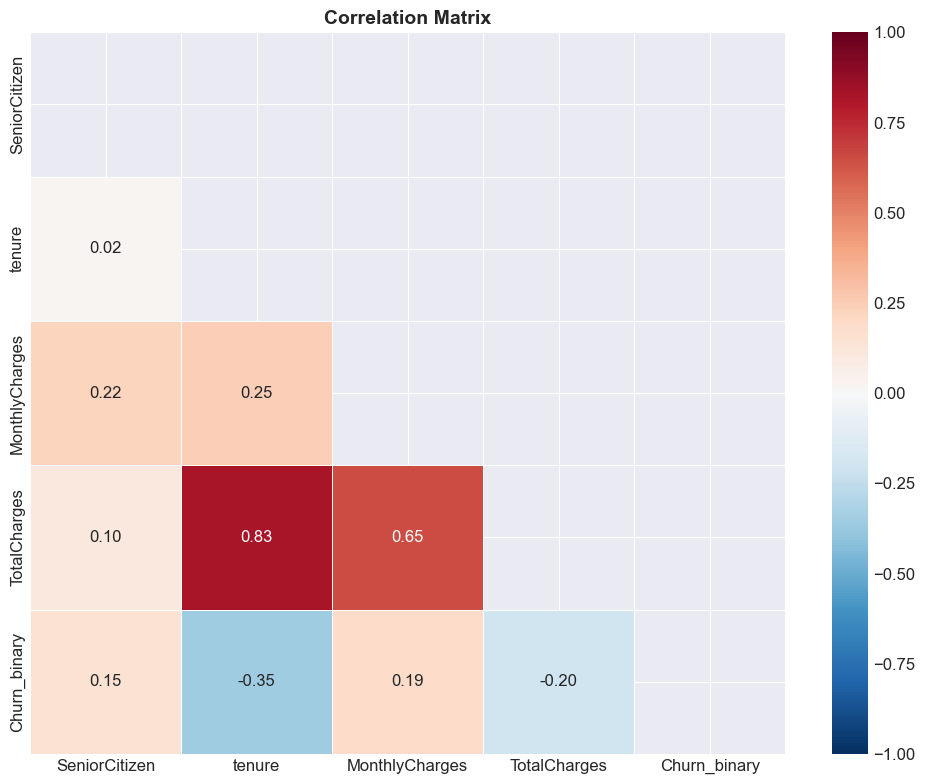


Top correlations with Churn:
  tenure              : -0.352  (↓ less churn)
  TotalCharges        : -0.199  (↓ less churn)
  MonthlyCharges      : +0.193  (↑ more churn)
  SeniorCitizen       : +0.151  (↑ more churn)


In [152]:
# ── Correlation heatmap (numeric features) ──
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with Churn
churn_corr = corr_matrix['Churn_binary'].drop('Churn_binary').sort_values(key=abs, ascending=False)
print("\nTop correlations with Churn:")
for feat, val in churn_corr.items():
    direction = "↑ more churn" if val > 0 else "↓ less churn"
    print(f"  {feat:20s}: {val:+.3f}  ({direction})")


### 2.6 Categorical Feature Analysis

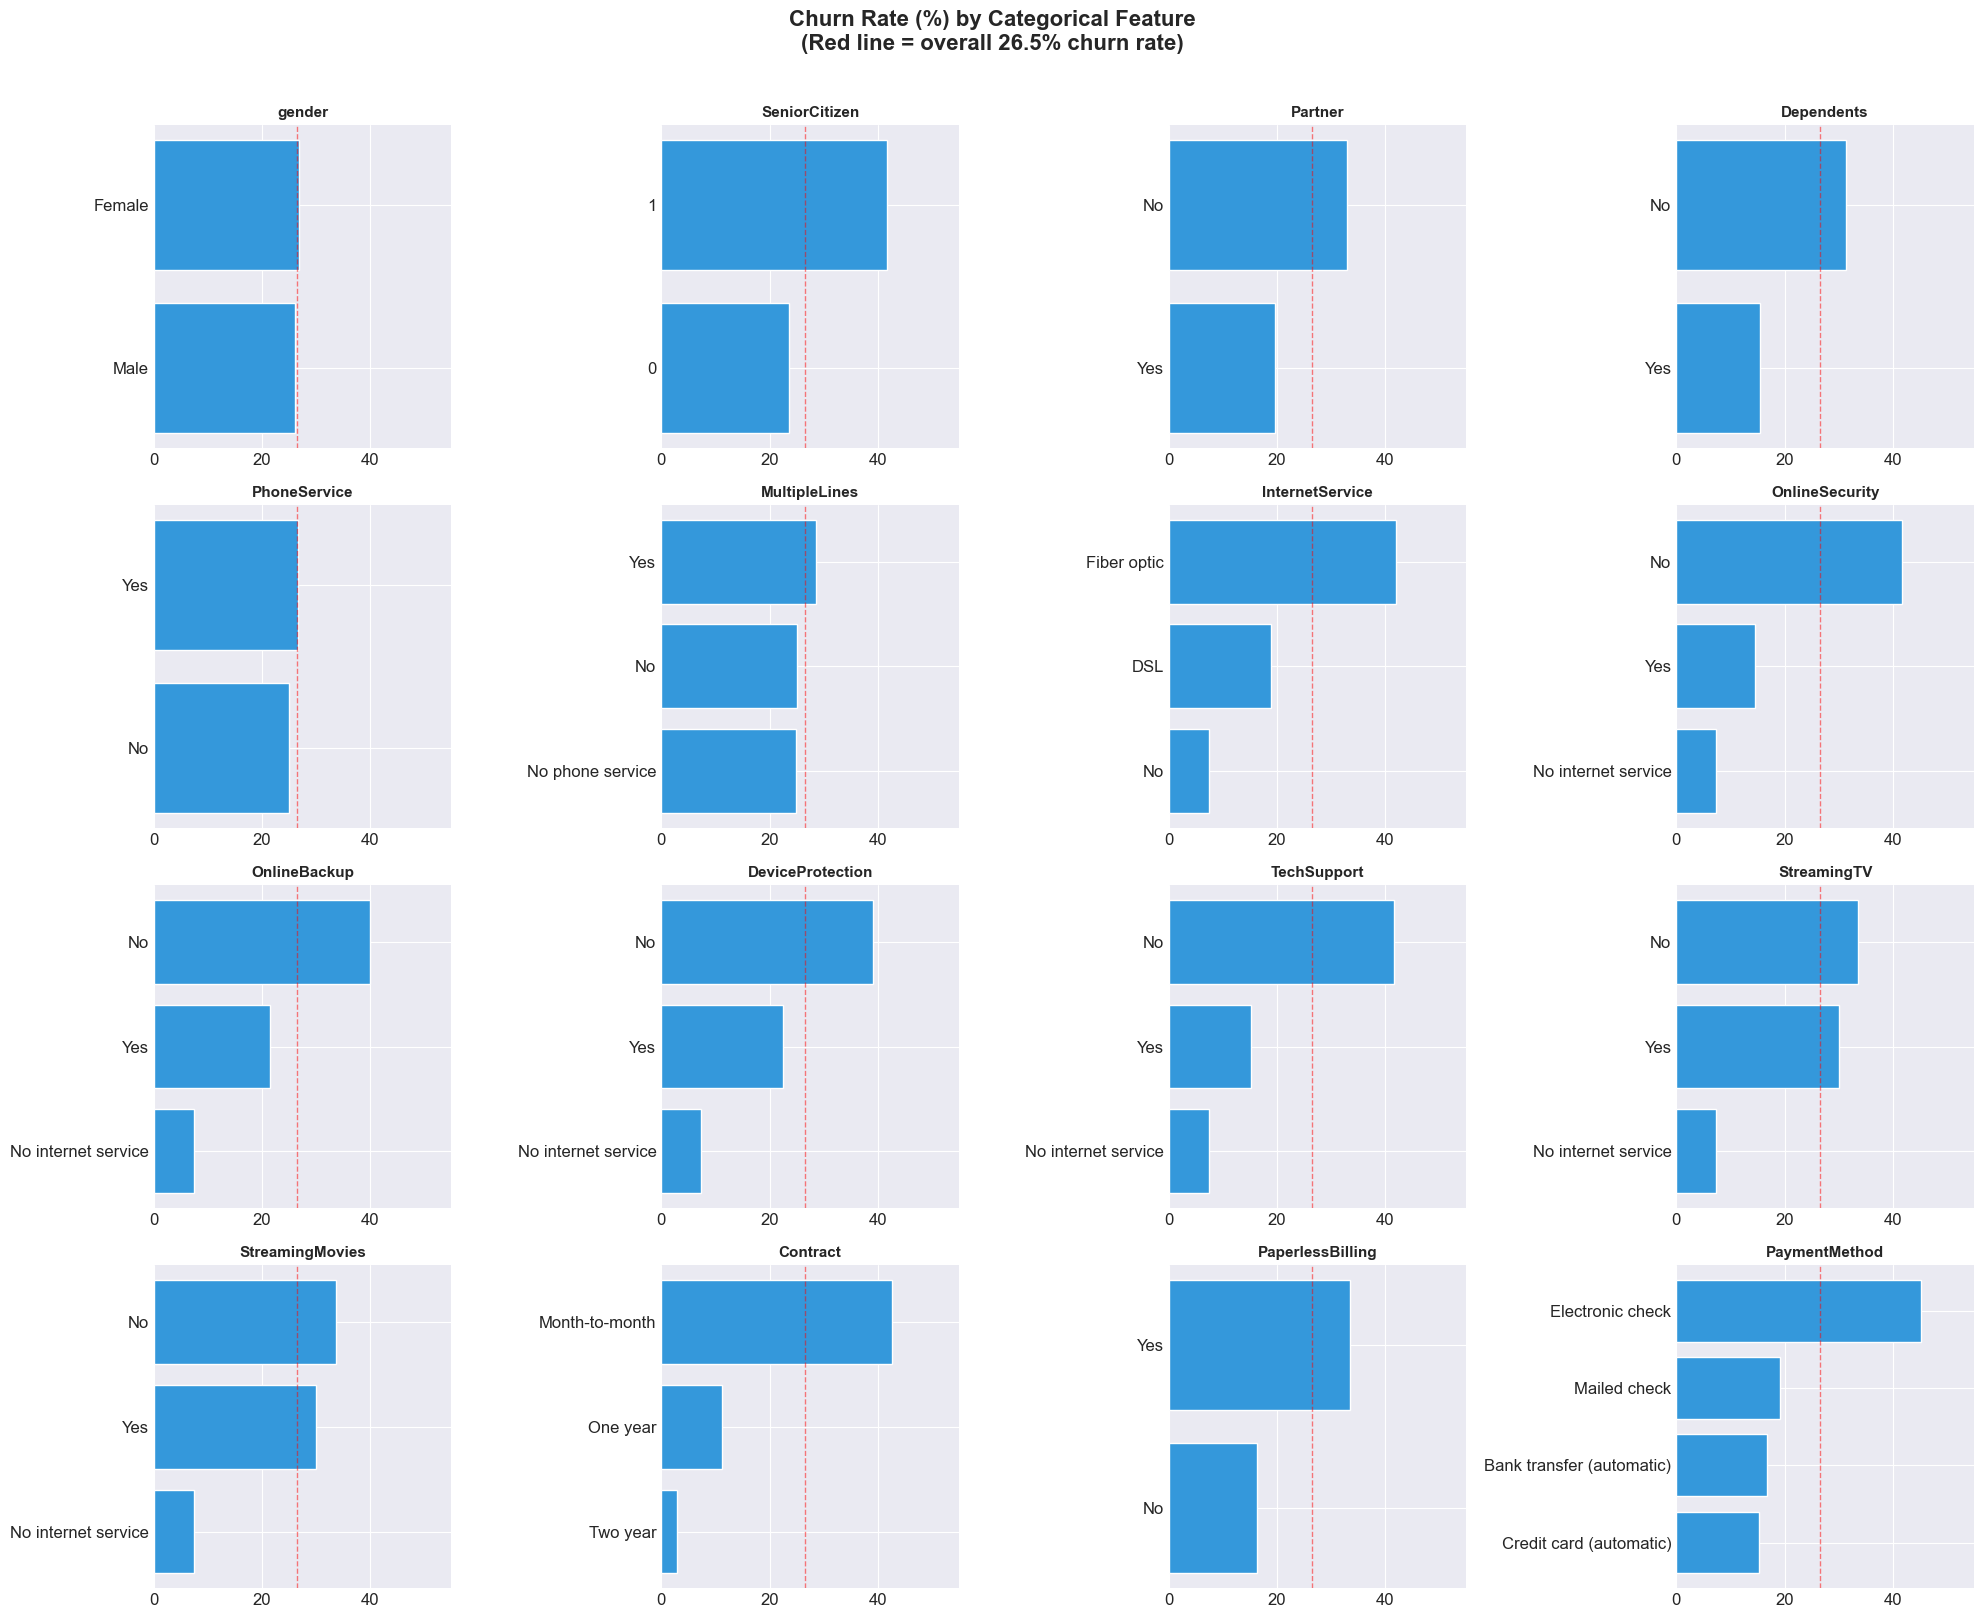

In [153]:
# ── Churn rate across all categorical features ──
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    churn_rate = df.groupby(feature)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate = churn_rate.sort_values(ascending=True)
    bars = axes[i].barh(churn_rate.index.astype(str), churn_rate.values * 100, color='#3498db', edgecolor='white')
    axes[i].set_title(feature, fontsize=11, fontweight='bold')
    axes[i].set_xlim(0, 55)
    axes[i].axvline(x=26.5, color='red', linestyle='--', alpha=0.5, linewidth=1)

plt.suptitle("Churn Rate (%) by Categorical Feature\n(Red line = overall 26.5% churn rate)",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
# 3. Feature Engineering

> **🎓 Instructor Note:** Feature engineering is the highest-leverage activity in ML. A Random Forest on great features will beat XGBoost on raw columns. Teach students to *think* about features: ratios, interactions, domain-driven buckets, temporal patterns.


In [154]:
# ── Engineered features ──

# 1. Charge-to-tenure ratio (how much is a new customer paying relative to loyalty?)
df['charge_tenure_ratio'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# 2. Average monthly charge (from total history)
df['avg_monthly_charge'] = df['TotalCharges'] / (df['tenure'] + 1)

# 3. Charge consistency (are they paying more now than their historical avg?)
df['charge_increase'] = df['MonthlyCharges'] - df['avg_monthly_charge']

# 4. Service bundle count
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['services_count'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

# 5. Has any protection service (security, backup, device protection)
df['has_protection'] = ((df['OnlineSecurity'] == 'Yes') |
                         (df['OnlineBackup'] == 'Yes') |
                         (df['DeviceProtection'] == 'Yes')).astype(int)

# 6. Has tech support
df['has_support'] = (df['TechSupport'] == 'Yes').astype(int)

# 7. Is new customer (tenure <= 6 months)
df['is_new_customer'] = (df['tenure'] <= 6).astype(int)

# 8. High value customer
df['is_high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)).astype(int)

# 9. Streaming bundled
df['has_streaming'] = ((df['StreamingTV'] == 'Yes') |
                        (df['StreamingMovies'] == 'Yes')).astype(int)

# 10. Vulnerable segment: new + month-to-month + no support
df['vulnerable_segment'] = ((df['is_new_customer'] == 1) &
                              (df['Contract'] == 'Month-to-month') &
                              (df['has_support'] == 0)).astype(int)

print("✓ 10 engineered features created")
print(f"\nNew columns: {df.shape[1]} total")
print(f"\nEngineered feature preview:")
print(df[['tenure', 'MonthlyCharges', 'charge_tenure_ratio', 'services_count',
           'vulnerable_segment']].head(10).to_string())


✓ 10 engineered features created

New columns: 32 total

Engineered feature preview:
   tenure  MonthlyCharges  charge_tenure_ratio  services_count  vulnerable_segment
0       1           29.85            14.925000               1                   1
1      34           56.95             1.627143               2                   0
2       2           53.85            17.950000               2                   1
3      45           42.30             0.919565               3                   0
4       2           70.70            23.566667               0                   1
5       8           99.65            11.072222               3                   0
6      22           89.10             3.873913               2                   0
7      10           29.75             2.704545               1                   0
8      28          104.80             3.613793               4                   0
9      62           56.15             0.891270               2                   0


### 3.1 Encode Categorical Variables

In [155]:
# ── Encode target ──
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# ── Drop ID and temporary columns ──
drop_cols = ['customerID', 'tenure_bucket']
df_model = df.drop(columns=drop_cols)

# ── One-hot encode categoricals ──
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode ({len(cat_cols)}):")
for col in cat_cols:
    print(f"  {col}: {df_model[col].nunique()} unique values → {list(df_model[col].unique())[:4]}...")

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f"\n✓ After encoding: {df_model.shape[1]} features")
print(f"\nFinal feature names ({df_model.shape[1] - 1}):")
feature_cols = [c for c in df_model.columns if c != 'Churn']
for i, col in enumerate(feature_cols):
    print(f"  {i+1:2d}. {col}")


Categorical columns to encode (15):
  gender: 2 unique values → ['Female', 'Male']...
  Partner: 2 unique values → ['Yes', 'No']...
  Dependents: 2 unique values → ['No', 'Yes']...
  PhoneService: 2 unique values → ['No', 'Yes']...
  MultipleLines: 3 unique values → ['No phone service', 'No', 'Yes']...
  InternetService: 3 unique values → ['DSL', 'Fiber optic', 'No']...
  OnlineSecurity: 3 unique values → ['No', 'Yes', 'No internet service']...
  OnlineBackup: 3 unique values → ['Yes', 'No', 'No internet service']...
  DeviceProtection: 3 unique values → ['No', 'Yes', 'No internet service']...
  TechSupport: 3 unique values → ['No', 'Yes', 'No internet service']...
  StreamingTV: 3 unique values → ['No', 'Yes', 'No internet service']...
  StreamingMovies: 3 unique values → ['No', 'Yes', 'No internet service']...
  Contract: 3 unique values → ['Month-to-month', 'One year', 'Two year']...
  PaperlessBilling: 2 unique values → ['Yes', 'No']...
  PaymentMethod: 4 unique values → ['Electron

---
# 4. Preprocessing Pipeline

> **⚠️ Common Pitfall — Data Leakage:** Never fit your scaler or SMOTE on the full dataset before splitting. Fit ONLY on `X_train`, then `transform` on `X_test`. SMOTE must also happen ONLY on the training set. Otherwise you're leaking test-set information into training.


In [156]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# ── Feature / target split ──
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# ── Train / test split (STRATIFIED to preserve class balance) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train set: {X_train.shape[0]:,} samples")
print(f"Test set:  {X_test.shape[0]:,} samples")
print(f"\nTrain churn rate: {y_train.mean():.3f}")
print(f"Test churn rate:  {y_test.mean():.3f}")
print(f"  → Stratification preserved ✓")


Train set: 5,634 samples
Test set:  1,409 samples

Train churn rate: 0.265
Test churn rate:  0.265
  → Stratification preserved ✓


In [157]:
# ── Impute missing values (fit on train ONLY) ──
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# ── Scale features (fit on train ONLY) ──
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),  # transform only, NOT fit_transform!
    columns=X_test.columns,
    index=X_test.index
)

print("✓ Missing values imputed with median, then StandardScaler applied")
print(f"Remaining NaNs in train: {X_train_scaled.isna().sum().sum()}")
print(f"Remaining NaNs in test:  {X_test_scaled.isna().sum().sum()}")
print(f"\nTrain mean (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"Train std  (should be ~1): {X_train_scaled.std().mean():.6f}")


✓ Missing values imputed with median, then StandardScaler applied
Remaining NaNs in train: 0
Remaining NaNs in test:  0

Train mean (should be ~0): -0.000000
Train std  (should be ~1): 1.000089


In [158]:
%pip install -q imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [159]:
# ── Handle class imbalance with SMOTE (on training set ONLY) ──
print(f"Before SMOTE:")
print(f"  Class 0 (Retained): {(y_train == 0).sum():,}")
print(f"  Class 1 (Churned):  {(y_train == 1).sum():,}")
print(f"  Ratio: {(y_train == 0).sum() / (y_train == 1).sum():.1f}:1")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(f"  Class 0 (Retained): {(y_train_resampled == 0).sum():,}")
print(f"  Class 1 (Churned):  {(y_train_resampled == 1).sum():,}")
print(f"  Ratio: {(y_train_resampled == 0).sum() / (y_train_resampled == 1).sum():.1f}:1 ✓")

print(f"\n⚠️ SMOTE was applied ONLY to training data.")
print(f"   Test set remains untouched ({X_test_scaled.shape[0]} samples, original distribution).")


Before SMOTE:
  Class 0 (Retained): 4,139
  Class 1 (Churned):  1,495
  Ratio: 2.8:1

After SMOTE:
  Class 0 (Retained): 4,139
  Class 1 (Churned):  4,139
  Ratio: 1.0:1 ✓

⚠️ SMOTE was applied ONLY to training data.
   Test set remains untouched (1409 samples, original distribution).


---
# 5. Model Training & Comparison

> **🎓 Instructor Note:** Always start with a baseline. If Logistic Regression gives 0.82 AUC, you need to *justify* the complexity of gradient boosting. Start simple, add complexity only when needed.


### 5.1 Baseline: Logistic Regression

In [160]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report, f1_score,
    precision_score, recall_score, accuracy_score
)
import time

def train_and_evaluate(model, model_name, X_tr, y_tr, X_te, y_te):
    """Train a model and return a standardized results dict."""
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results = {
        'Model': model_name,
        'ROC-AUC': roc_auc_score(y_te, y_proba),
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'Train Time (s)': round(train_time, 2)
    }

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_te, y_pred, target_names=['Retained', 'Churned']))
    print(f"  ROC-AUC:    {results['ROC-AUC']:.4f}")
    print(f"  Train time: {train_time:.2f}s")

    return results, model, y_pred, y_proba

# ── Logistic Regression (Baseline) ──
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_results, lr_fitted, lr_pred, lr_proba = train_and_evaluate(
    lr_model, "Logistic Regression", X_train_resampled, y_train_resampled, X_test_scaled, y_test
)



  Logistic Regression
              precision    recall  f1-score   support

    Retained       0.90      0.74      0.81      1035
     Churned       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

  ROC-AUC:    0.8431
  Train time: 0.04s


### 5.2 Random Forest

In [161]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_results, rf_fitted, rf_pred, rf_proba = train_and_evaluate(
    rf_model, "Random Forest", X_train_resampled, y_train_resampled, X_test_scaled, y_test
)



  Random Forest
              precision    recall  f1-score   support

    Retained       0.88      0.80      0.84      1035
     Churned       0.55      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409

  ROC-AUC:    0.8379
  Train time: 0.61s


### 5.3 XGBoost

In [162]:
%pip install -q xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [163]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handle imbalance
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_results, xgb_fitted, xgb_pred, xgb_proba = train_and_evaluate(
    xgb_model, "XGBoost", X_train_resampled, y_train_resampled, X_test_scaled, y_test
)



  XGBoost
              precision    recall  f1-score   support

    Retained       0.88      0.77      0.82      1035
     Churned       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

  ROC-AUC:    0.8253
  Train time: 0.72s


### 5.4 LightGBM

In [164]:
%pip install -q lightgbm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [165]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    num_leaves=31,
    max_depth=-1,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    verbose=-1
)

lgbm_results, lgbm_fitted, lgbm_pred, lgbm_proba = train_and_evaluate(
    lgbm_model, "LightGBM", X_train_resampled, y_train_resampled, X_test_scaled, y_test
)



  LightGBM
              precision    recall  f1-score   support

    Retained       0.85      0.85      0.85      1035
     Churned       0.59      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409

  ROC-AUC:    0.8288
  Train time: 1.72s


### 5.5 Model Comparison Leaderboard

In [166]:
# ── Compare all models ──
all_results = pd.DataFrame([lr_results, rf_results, xgb_results, lgbm_results])
all_results = all_results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
all_results.index = ['🥇', '🥈', '🥉', '4th']

print("\n" + "=" * 80)
print("  MODEL LEADERBOARD")
print("=" * 80)
print(all_results.to_string())
print("\n🔑 Best model by ROC-AUC: " + all_results.iloc[0]['Model'])



  MODEL LEADERBOARD
                   Model   ROC-AUC  Accuracy  Precision    Recall        F1  Train Time (s)
🥇    Logistic Regression  0.843104  0.748048   0.516814  0.780749  0.621938            0.04
🥈          Random Forest  0.837934  0.770050   0.553191  0.695187  0.616114            0.61
🥉               LightGBM  0.828802  0.779276   0.585831  0.574866  0.580297            1.72
4th              XGBoost  0.825269  0.757275   0.531496  0.721925  0.612245            0.72

🔑 Best model by ROC-AUC: Logistic Regression


---
# 6. Evaluation Deep Dive

> **⚠️ The Accuracy Trap:** A model that predicts "No Churn" for everyone gets 73.5% accuracy. Your students *will* celebrate that number if you don't teach them why it's meaningless.


### 6.1 ROC Curves

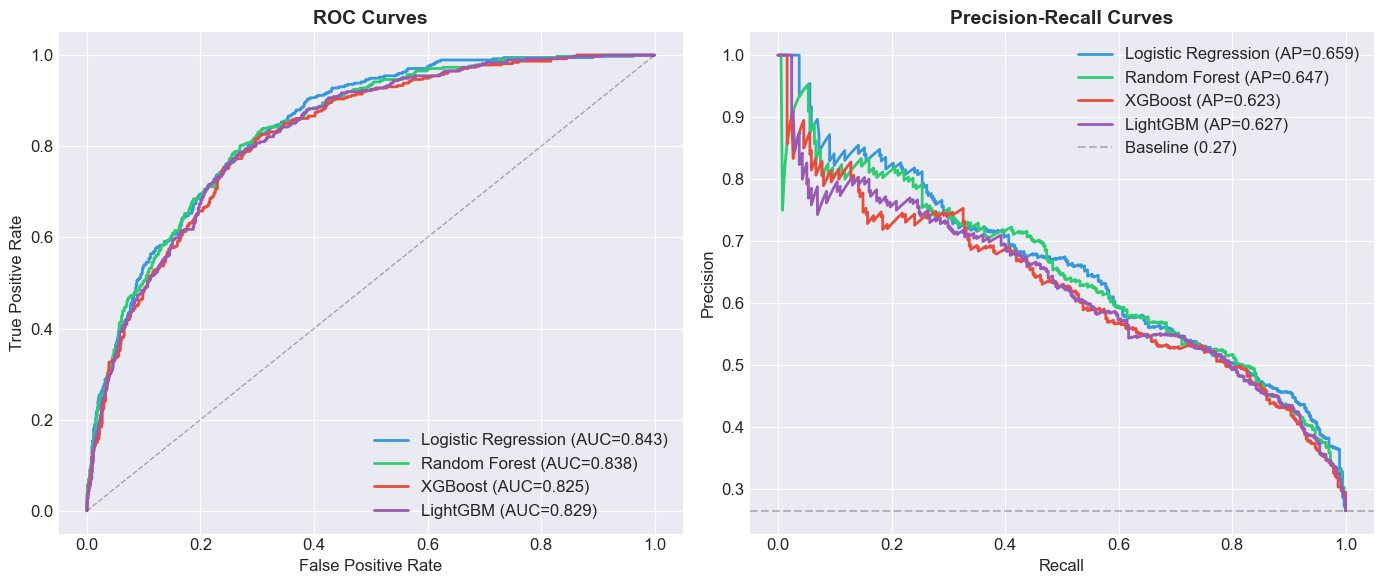

In [167]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── ROC Curves ──
models_data = [
    ('Logistic Regression', lr_proba, '#3498db'),
    ('Random Forest', rf_proba, '#2ecc71'),
    ('XGBoost', xgb_proba, '#e74c3c'),
    ('LightGBM', lgbm_proba, '#9b59b6'),
]

for name, proba, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')

# ── Precision-Recall Curves ──
for name, proba, color in models_data:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')

axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


### 6.2 Confusion Matrix (Best Model)

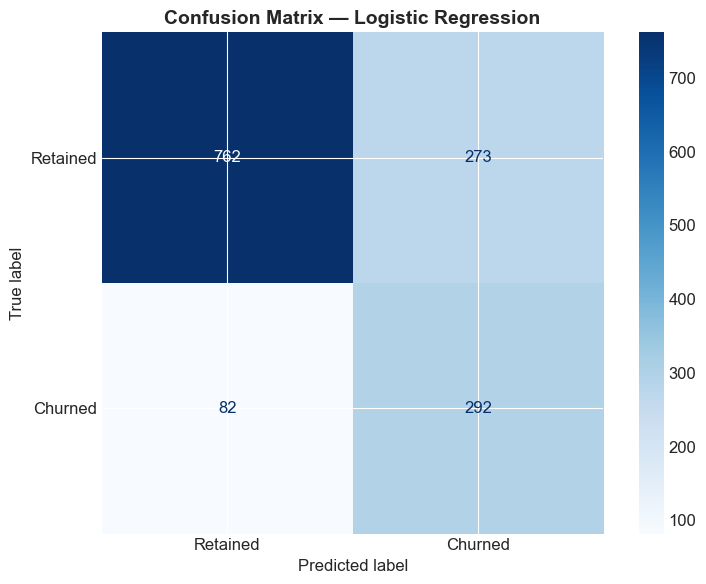


📊 Confusion Matrix Breakdown (Logistic Regression):
  True Negatives  (TN): 762 — Correctly predicted 'stay'
  False Positives (FP): 273 — False alarm (predicted churn, actually stayed) → cost: wasted discount
  False Negatives (FN): 82 — MISSED churner (predicted stay, actually left) → cost: lost customer 💰
  True Positives  (TP): 292 — Correctly caught churner → opportunity to intervene

  Churners caught: 292/374 (78.1%)
  Churners missed: 82/374 (21.9%)


In [168]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the best model (highest AUC)
best_name = all_results.iloc[0]['Model']
best_proba = {'Logistic Regression': lr_proba, 'Random Forest': rf_proba,
              'XGBoost': xgb_proba, 'LightGBM': lgbm_proba}[best_name]
best_pred = {'Logistic Regression': lr_pred, 'Random Forest': rf_pred,
             'XGBoost': xgb_pred, 'LightGBM': lgbm_pred}[best_name]

cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Confusion Matrix Breakdown ({best_name}):")
print(f"  True Negatives  (TN): {tn:,} — Correctly predicted 'stay'")
print(f"  False Positives (FP): {fp:,} — False alarm (predicted churn, actually stayed) → cost: wasted discount")
print(f"  False Negatives (FN): {fn:,} — MISSED churner (predicted stay, actually left) → cost: lost customer 💰")
print(f"  True Positives  (TP): {tp:,} — Correctly caught churner → opportunity to intervene")
print(f"\n  Churners caught: {tp}/{tp+fn} ({tp/(tp+fn):.1%})")
print(f"  Churners missed: {fn}/{tp+fn} ({fn/(tp+fn):.1%})")


### 6.3 Threshold Optimization

> **🎓 Instructor Note:** The default 0.5 threshold rarely optimal in business. If saving a churner is worth $500 and a false alarm costs $20, the optimal threshold is much lower than 0.5. This bridges ML to business impact.


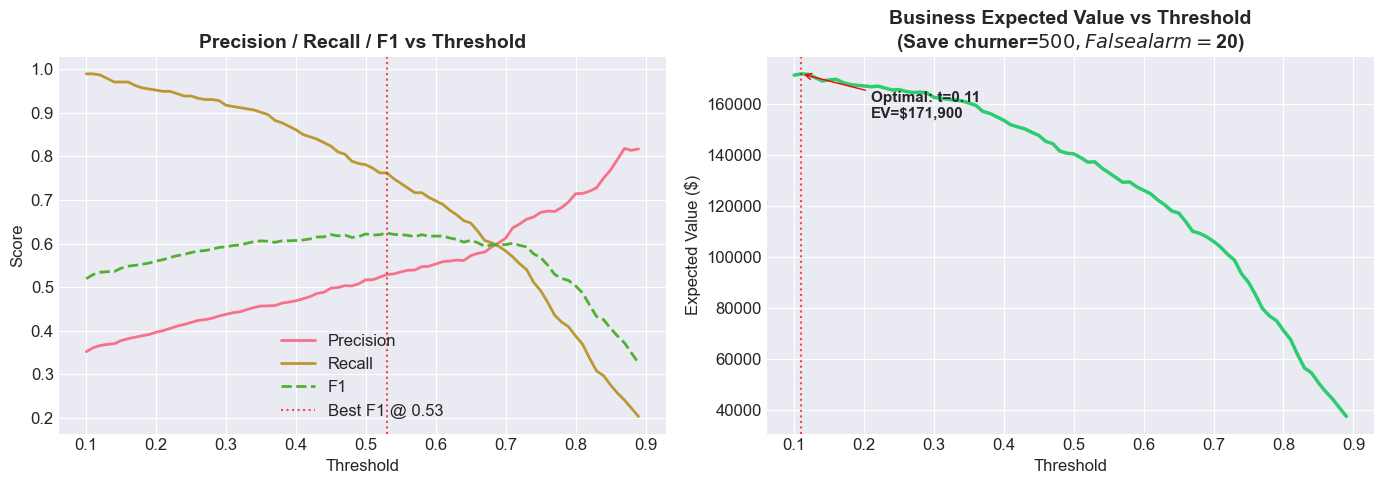


🎯 Optimal threshold by F1: 0.53
🎯 Optimal threshold by Expected Value: 0.11
   → At this threshold: 370/374 churners caught, 655 false alarms


In [169]:
# ── Threshold optimization ──
thresholds = np.arange(0.1, 0.9, 0.01)
results_by_threshold = []

for t in thresholds:
    y_pred_t = (best_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results_by_threshold.append({
        'threshold': t,
        'precision': tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0,
        'recall': tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0,
        'f1': f1_score(y_test, y_pred_t),
        'churners_caught': tp_t,
        'false_alarms': fp_t,
        # Business: saving a churner = $500, false alarm = $20
        'expected_value': tp_t * 500 - fp_t * 20
    })

df_thresh = pd.DataFrame(results_by_threshold)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot precision, recall, F1 vs threshold
axes[0].plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', linewidth=2)
axes[0].plot(df_thresh['threshold'], df_thresh['recall'], label='Recall', linewidth=2)
axes[0].plot(df_thresh['threshold'], df_thresh['f1'], label='F1', linewidth=2, linestyle='--')
best_f1_thresh = df_thresh.loc[df_thresh['f1'].idxmax(), 'threshold']
axes[0].axvline(x=best_f1_thresh, color='red', linestyle=':', alpha=0.7, label=f'Best F1 @ {best_f1_thresh:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold', fontsize=14, fontweight='bold')
axes[0].legend()

# Plot expected business value
axes[1].plot(df_thresh['threshold'], df_thresh['expected_value'], linewidth=2.5, color='#2ecc71')
best_ev_thresh = df_thresh.loc[df_thresh['expected_value'].idxmax(), 'threshold']
best_ev = df_thresh['expected_value'].max()
axes[1].axvline(x=best_ev_thresh, color='red', linestyle=':', alpha=0.7)
axes[1].annotate(f'Optimal: t={best_ev_thresh:.2f}\nEV=${best_ev:,.0f}',
                 xy=(best_ev_thresh, best_ev), xytext=(best_ev_thresh+0.1, best_ev*0.9),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Expected Value ($)')
axes[1].set_title('Business Expected Value vs Threshold\n(Save churner=$500, False alarm=$20)',
                   fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🎯 Optimal threshold by F1: {best_f1_thresh:.2f}")
print(f"🎯 Optimal threshold by Expected Value: {best_ev_thresh:.2f}")
print(f"   → At this threshold: {df_thresh.loc[df_thresh['expected_value'].idxmax(), 'churners_caught']}"
      f"/{(y_test==1).sum()} churners caught, "
      f"{df_thresh.loc[df_thresh['expected_value'].idxmax(), 'false_alarms']} false alarms")


---
# 7. MLflow Experiment Tracking

> **🎓 Instructor Note:** Without experiment tracking, ML is alchemy. "Which model was better — the one I trained Tuesday or the one from last week?" MLflow makes experiments reproducible and comparable.


In [170]:
%pip install -q mlflow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [171]:
import mlflow
import mlflow.sklearn

# ── Set up MLflow ──
mlflow.set_experiment("telecom-churn-prediction")

# ── Log each model as a separate run ──
models_to_log = [
    ("logistic-regression-baseline", lr_fitted, lr_results, lr_proba),
    ("random-forest-v1", rf_fitted, rf_results, rf_proba),
    ("xgboost-tuned-v1", xgb_fitted, xgb_results, xgb_proba),
    ("lightgbm-tuned-v1", lgbm_fitted, lgbm_results, lgbm_proba),
]

for run_name, model_obj, results, proba in models_to_log:
    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_param("model_type", results['Model'])
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_param("imbalance_strategy", "SMOTE")
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("scaler", "StandardScaler")

        # Log metrics
        mlflow.log_metric("roc_auc", results['ROC-AUC'])
        mlflow.log_metric("accuracy", results['Accuracy'])
        mlflow.log_metric("precision", results['Precision'])
        mlflow.log_metric("recall", results['Recall'])
        mlflow.log_metric("f1", results['F1'])

        # Log model artifact
        mlflow.sklearn.log_model(model_obj, "model")

        print(f"  ✓ Logged: {run_name} (AUC={results['ROC-AUC']:.4f})")

print(f"\n✓ All {len(models_to_log)} experiments logged to MLflow")
print(f"\nView the MLflow UI: run 'mlflow ui' in terminal, then open http://localhost:5000")


2026/04/20 12:51:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 12:51:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/20 12:51:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 12:51:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

  ✓ Logged: logistic-regression-baseline (AUC=0.8431)


2026/04/20 12:51:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 12:51:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Logged: random-forest-v1 (AUC=0.8379)


2026/04/20 12:51:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 12:51:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Logged: xgboost-tuned-v1 (AUC=0.8253)
  ✓ Logged: lightgbm-tuned-v1 (AUC=0.8288)

✓ All 4 experiments logged to MLflow

View the MLflow UI: run 'mlflow ui' in terminal, then open http://localhost:5000


### 7.1 Register Best Model

In [172]:
# ── Register the best model in the Model Registry ──
best_model_name = all_results.iloc[0]['Model']
best_run_name = {
    'Logistic Regression': 'logistic-regression-baseline',
    'Random Forest': 'random-forest-v1',
    'XGBoost': 'xgboost-tuned-v1',
    'LightGBM': 'lightgbm-tuned-v1'
}[best_model_name]

# Find the run ID
runs = mlflow.search_runs(experiment_names=["telecom-churn-prediction"])
best_run = runs[runs['tags.mlflow.runName'] == best_run_name].iloc[0]
best_run_id = best_run['run_id']

# Register
model_uri = f"runs:/{best_run_id}/model"
registered_model = mlflow.register_model(model_uri, "telecom-churn-classifier")

print(f"\n✓ Model registered: telecom-churn-classifier")
print(f"  Version: {registered_model.version}")
print(f"  Source run: {best_run_name}")
print(f"  AUC: {best_run['metrics.roc_auc']:.4f}")


Registered model 'telecom-churn-classifier' already exists. Creating a new version of this model...
2026/04/20 12:51:43 WARNING mlflow.tracking._model_registry.fluent: Run with id 00acac8ecff4405282a1de0ac8caf456 has no artifacts at artifact path 'model', registering model based on models:/m-5b26d75727004f6eb218eb9fc82be1bb instead



✓ Model registered: telecom-churn-classifier
  Version: 4
  Source run: logistic-regression-baseline
  AUC: 0.8431


Created version '4' of model 'telecom-churn-classifier'.


---
# 8. Feature Importance & Explainability

Understanding *why* your model makes decisions is crucial for production trust and debugging.


### 8.1 Built-in Feature Importance

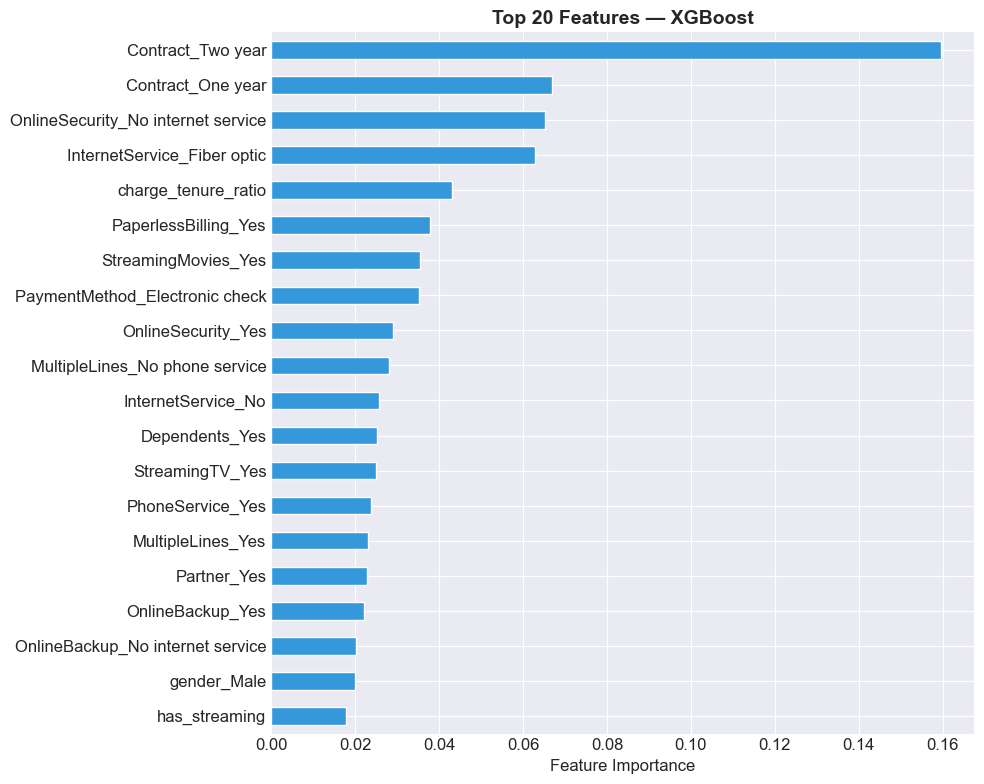


🔑 Top 5 most important features:
  1. Contract_Two year: 0.1595
  2. Contract_One year: 0.0669
  3. OnlineSecurity_No internet service: 0.0652
  4. InternetService_Fiber optic: 0.0628
  5. charge_tenure_ratio: 0.0431


In [173]:
# ── Feature importance from tree-based models ──
best_tree_model = {'Random Forest': rf_fitted, 'XGBoost': xgb_fitted, 'LightGBM': lgbm_fitted}
tree_model = best_tree_model.get(best_model_name, xgb_fitted)
tree_name = best_model_name if best_model_name in best_tree_model else 'XGBoost'

importances = pd.Series(tree_model.feature_importances_, index=X_train.columns)
top_20 = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_20.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top 20 Features — {tree_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔑 Top 5 most important features:")
for i, (feat, imp) in enumerate(importances.sort_values(ascending=False).head(5).items()):
    print(f"  {i+1}. {feat}: {imp:.4f}")


### 8.2 SHAP Values (Model Explainability)

In [174]:
%pip install -q shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


SHAP Summary Plot — shows how each feature pushes predictions toward churn or retention:


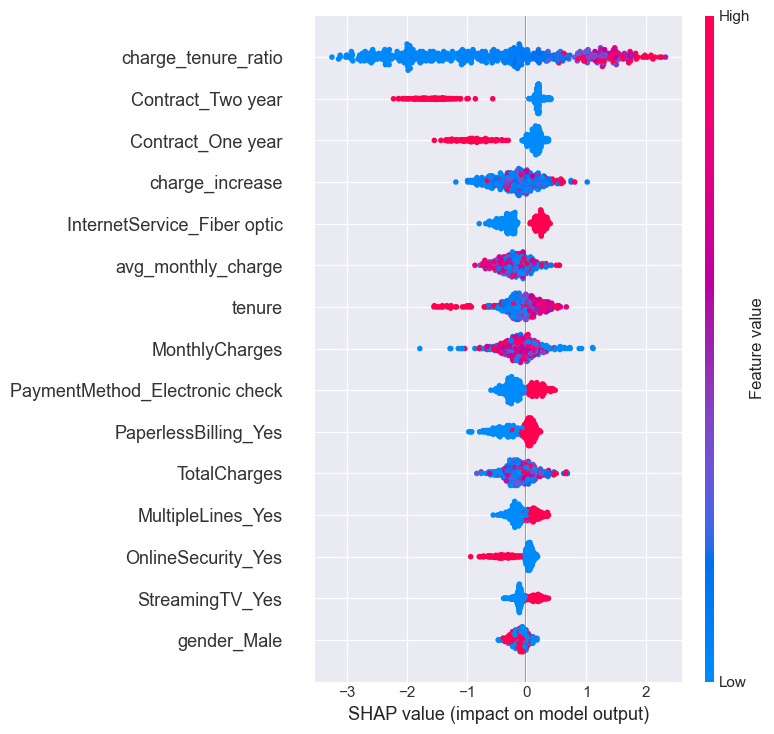

In [175]:
import shap

# ── SHAP explainer ──
# Use a sample for speed
X_sample = X_test_scaled.sample(500, random_state=42)

explainer = shap.TreeExplainer(xgb_fitted)
shap_values = explainer.shap_values(X_sample)

# ── Summary plot ──
print("SHAP Summary Plot — shows how each feature pushes predictions toward churn or retention:")
shap.summary_plot(shap_values, X_sample, plot_type="dot", max_display=15, show=True)


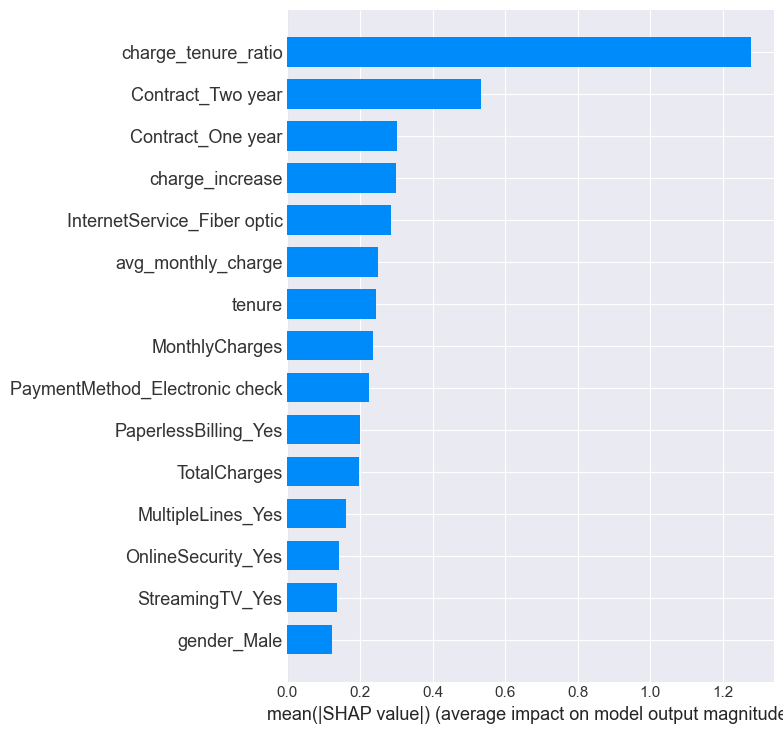

In [176]:
# ── SHAP bar plot (mean absolute impact) ──
shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=15, show=True)


Customer prediction: 69.9% churn probability
Actual: Churned ✓

SHAP waterfall — what drove THIS specific prediction:


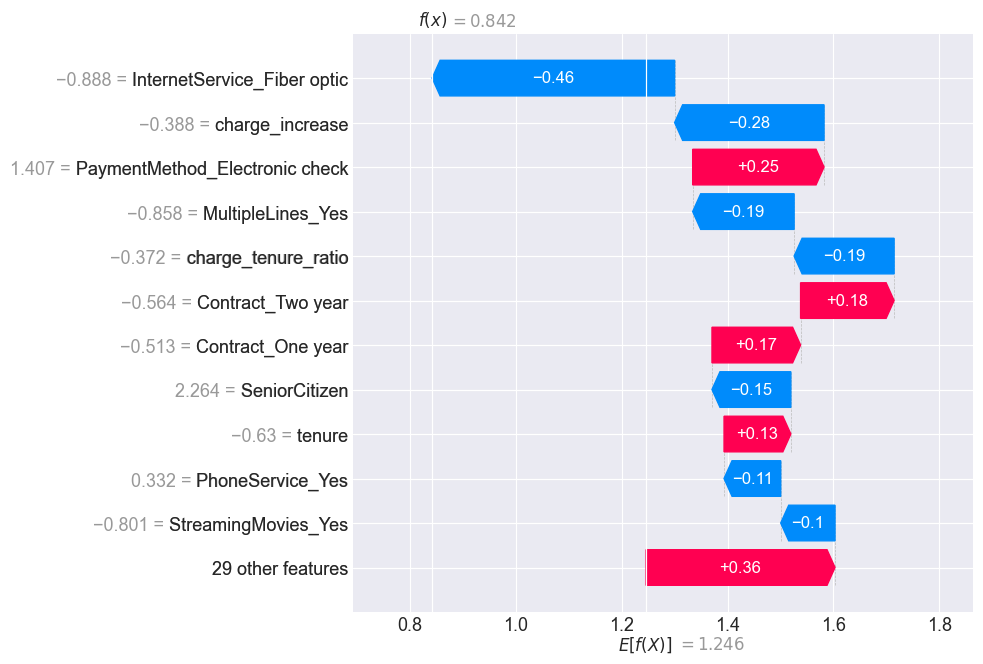

In [177]:
# ── Explain a single prediction ──
# Pick a customer who churned
churned_customers = X_test_scaled[y_test == 1]
sample_customer = churned_customers.iloc[0:1]
sample_idx = sample_customer.index[0]
sample_proba = xgb_fitted.predict_proba(sample_customer)[0, 1]

print(f"Customer prediction: {sample_proba:.1%} churn probability")
print(f"Actual: {'Churned ✓' if y_test.loc[sample_idx] == 1 else 'Retained'}")
print("\nSHAP waterfall — what drove THIS specific prediction:")

explainer_single = shap.TreeExplainer(xgb_fitted)
shap_single = explainer_single(sample_customer)
shap.waterfall_plot(shap_single[0], max_display=12, show=True)


---
# 9. Deployment

> **🎓 Instructor Note:** A model in a notebook is a science experiment. A model behind an API is a product. This section bridges the gap.


### 9.1 Save Model Artifacts for Deployment

In [178]:
import joblib
import json

# ── Save the best model and scaler ──
best_fitted = {'Logistic Regression': lr_fitted, 'Random Forest': rf_fitted,
               'XGBoost': xgb_fitted, 'LightGBM': lgbm_fitted}[best_model_name]

joblib.dump(best_fitted, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save feature names for validation
feature_config = {
    'model_name': best_model_name,
    'features': list(X_train.columns),
    'n_features': len(X_train.columns),
    'optimal_threshold': float(best_ev_thresh),
    'training_date': pd.Timestamp.now().isoformat(),
    'metrics': {
        'roc_auc': float(all_results.iloc[0]['ROC-AUC']),
        'f1': float(all_results.iloc[0]['F1']),
        'recall': float(all_results.iloc[0]['Recall']),
    }
}
with open('model_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

print("✓ Artifacts saved:")
print("  churn_model.pkl    — trained model")
print("  scaler.pkl         — fitted StandardScaler")
print("  model_config.json  — feature names, threshold, metadata")


✓ Artifacts saved:
  churn_model.pkl    — trained model
  scaler.pkl         — fitted StandardScaler
  model_config.json  — feature names, threshold, metadata


### 9.2 FastAPI Application

Save the following as `app.py` in your deployment directory:


In [179]:
# Save this cell as: app.py
# Run: uvicorn app:app --reload --port 8000

fastapi_code = '''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib, json, pandas as pd, numpy as np

model = joblib.load("churn_model.pkl")
scaler = joblib.load("scaler.pkl")
with open("model_config.json") as f:
    config = json.load(f)

app = FastAPI(title="Telecom Churn Prediction API", version="1.0.0")

class CustomerInput(BaseModel):
    tenure: int
    MonthlyCharges: float
    TotalCharges: float
    Contract: str          # "Month-to-month", "One year", "Two year"
    InternetService: str   # "DSL", "Fiber optic", "No"
    OnlineSecurity: str    # "Yes", "No", "No internet service"
    TechSupport: str       # "Yes", "No", "No internet service"
    PaymentMethod: str
    PaperlessBilling: str  # "Yes", "No"
    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str

class PredictionOutput(BaseModel):
    churn_probability: float
    risk_level: str
    recommended_action: str
    model_version: str

@app.get("/health")
def health():
    return {"status": "healthy", "model": config["model_name"]}

@app.post("/predict", response_model=PredictionOutput)
def predict(customer: CustomerInput):
    try:
        data = customer.dict()
        # Engineer features
        data["charge_tenure_ratio"] = data["MonthlyCharges"] / (data["tenure"] + 1)
        data["avg_monthly_charge"] = data["TotalCharges"] / (data["tenure"] + 1)
        data["charge_increase"] = data["MonthlyCharges"] - data["avg_monthly_charge"]
        data["services_count"] = sum(1 for s in [data["OnlineSecurity"], data["TechSupport"]] if s == "Yes")
        data["has_protection"] = int(data["OnlineSecurity"] == "Yes")
        data["has_support"] = int(data["TechSupport"] == "Yes")
        data["is_new_customer"] = int(data["tenure"] <= 6)
        data["is_high_value"] = int(data["MonthlyCharges"] > 70)
        data["has_streaming"] = 0
        data["vulnerable_segment"] = int(
            data["is_new_customer"] and data["Contract"] == "Month-to-month"
            and not data["has_support"]
        )
        df = pd.DataFrame([data])
        df = pd.get_dummies(df)
        for col in config["features"]:
            if col not in df.columns:
                df[col] = 0
        df = df[config["features"]]
        df_scaled = scaler.transform(df)
        proba = float(model.predict_proba(df_scaled)[0, 1])
        threshold = config["optimal_threshold"]
        if proba > 0.6:
            risk, action = "CRITICAL", "Immediate retention call + loyalty offer"
        elif proba > threshold:
            risk, action = "HIGH", "Trigger automated retention campaign"
        elif proba > 0.2:
            risk, action = "MEDIUM", "Add to watch list, send survey"
        else:
            risk, action = "LOW", "Standard engagement"
        return PredictionOutput(
            churn_probability=round(proba, 4),
            risk_level=risk,
            recommended_action=action,
            model_version=config["model_name"]
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
'''

with open("app.py", "w") as f:
    f.write(fastapi_code)

print("app.py saved")
print("Run locally: uvicorn app:app --reload --port 8000")
print("Swagger UI: http://localhost:8000/docs")


app.py saved
Run locally: uvicorn app:app --reload --port 8000
Swagger UI: http://localhost:8000/docs


### 9.3 Dockerfile

In [180]:
dockerfile = '''FROM python:3.10-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY app.py .
COPY churn_model.pkl .
COPY scaler.pkl .
COPY model_config.json .
EXPOSE 8000
HEALTHCHECK --interval=30s --timeout=5s CMD curl -f http://localhost:8000/health || exit 1
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

requirements = '''fastapi==0.104.1
uvicorn==0.24.0
pandas==2.1.4
numpy==1.26.2
scikit-learn==1.3.2
xgboost==2.0.3
joblib==1.3.2
'''

with open("Dockerfile", "w") as f:
    f.write(dockerfile)
with open("requirements.txt", "w") as f:
    f.write(requirements)

print("Dockerfile saved")
print("requirements.txt saved")
print("\nBuild & run:")
print("  docker build -t churn-api .")
print("  docker run -p 8000:8000 churn-api")


Dockerfile saved
requirements.txt saved

Build & run:
  docker build -t churn-api .
  docker run -p 8000:8000 churn-api


### 9.4 Batch Inference Script

In [181]:
# Batch inference script - save as batch_predict.py
# Schedule with cron: 0 2 * * * python batch_predict.py

batch_script = '''
import pandas as pd
import joblib, json
from datetime import datetime

model = joblib.load('churn_model.pkl')
scaler = joblib.load('scaler.pkl')
with open('model_config.json') as f:
    config = json.load(f)

# Load active customers (replace with your data source)
customers = pd.read_csv('active_customers.csv')
customer_ids = customers['customerID']

# Preprocess: same pipeline as training
# ... feature engineering, encoding, scaling ...

# Predict
probas = model.predict_proba(customers_scaled)[:, 1]

# Build output
output = pd.DataFrame({
    'customerID': customer_ids,
    'churn_probability': probas,
    'risk_level': pd.cut(probas, bins=[0, 0.2, 0.4, 0.6, 1.0],
                          labels=['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']),
    'scored_at': datetime.utcnow().isoformat()
})

high_risk = output[output['risk_level'].isin(['HIGH', 'CRITICAL'])]
output.to_csv(f'predictions_{datetime.utcnow().strftime("%Y%m%d")}.csv', index=False)
high_risk.to_csv('high_risk_customers.csv', index=False)
print(f'Scored: {len(output):,} customers')
print(f'High-risk: {len(high_risk):,}')
'''

with open("batch_predict.py", "w") as f:
    f.write(batch_script)

print("batch_predict.py saved")
print("Schedule: 0 2 * * * cd /app && python batch_predict.py")


batch_predict.py saved
Schedule: 0 2 * * * cd /app && python batch_predict.py


---
# 10. Production Monitoring

> **🎓 Instructor Note:** A deployed model is not a finished product — it's a living system. Customer behavior shifts, competitors launch offers, pricing changes. Without monitoring, your model silently goes stale.


### 10.1 Data Drift Detection

In [182]:
from scipy.stats import ks_2samp

def detect_drift(reference: pd.DataFrame, production: pd.DataFrame,
                 threshold: float = 0.05) -> pd.DataFrame:
    """
    Detect feature drift using Kolmogorov-Smirnov test.

    Parameters:
        reference: Training data distribution (X_train_scaled sample)
        production: Recent production data
        threshold: p-value threshold for drift detection

    Returns:
        DataFrame with drift statistics per feature
    """
    results = []
    for col in reference.columns:
        stat, p_value = ks_2samp(reference[col].dropna(), production[col].dropna())
        results.append({
            'feature': col,
            'ks_statistic': round(stat, 4),
            'p_value': round(p_value, 4),
            'drift_detected': p_value < threshold
        })

    return pd.DataFrame(results).sort_values('ks_statistic', ascending=False)

# ── Simulate production data (add some drift to MonthlyCharges) ──
np.random.seed(42)
X_production = X_test_scaled.copy()
# Simulate a pricing change: shift MonthlyCharges up
X_production['MonthlyCharges'] = X_production['MonthlyCharges'] + np.random.normal(0.3, 0.1, len(X_production))
X_production['charge_tenure_ratio'] = X_production['charge_tenure_ratio'] + np.random.normal(0.2, 0.1, len(X_production))

# ── Run drift detection ──
drift_report = detect_drift(X_train_scaled.sample(1000, random_state=42), X_production)

print("=" * 60)
print("  DATA DRIFT REPORT")
print("=" * 60)
print(f"\nFeatures analyzed: {len(drift_report)}")
print(f"Features with drift: {drift_report['drift_detected'].sum()}")
print(f"\nDrifted features:")
drifted = drift_report[drift_report['drift_detected']]
if len(drifted) > 0:
    print(drifted.to_string(index=False))
else:
    print("  None detected ✓")


  DATA DRIFT REPORT

Features analyzed: 40
Features with drift: 2

Drifted features:
            feature  ks_statistic  p_value  drift_detected
charge_tenure_ratio        0.4365      0.0            True
     MonthlyCharges        0.1850      0.0            True


### 10.2 Model Performance Monitoring

In [183]:
def monitor_model_performance(y_true, y_proba, threshold,
                               auc_floor=0.80, recall_floor=0.55):
    """
    Check if the model still meets production performance thresholds.
    Returns alerts if performance has degraded.
    """
    from sklearn.metrics import roc_auc_score, recall_score, precision_score

    y_pred = (y_proba >= threshold).astype(int)

    current_auc = roc_auc_score(y_true, y_proba)
    current_recall = recall_score(y_true, y_pred)
    current_precision = precision_score(y_true, y_pred)

    alerts = []
    if current_auc < auc_floor:
        alerts.append(f"🚨 AUC BELOW THRESHOLD: {current_auc:.4f} < {auc_floor}")
    if current_recall < recall_floor:
        alerts.append(f"🚨 RECALL BELOW THRESHOLD: {current_recall:.4f} < {recall_floor}")

    return {
        'auc': current_auc,
        'recall': current_recall,
        'precision': current_precision,
        'alerts': alerts,
        'status': 'DEGRADED' if alerts else 'HEALTHY'
    }

# ── Run performance check ──
perf = monitor_model_performance(y_test, best_proba, best_ev_thresh)

print("=" * 60)
print("  MODEL PERFORMANCE MONITOR")
print("=" * 60)
print(f"\n  Status:    {'🟢 ' + perf['status'] if perf['status'] == 'HEALTHY' else '🔴 ' + perf['status']}")
print(f"  AUC:       {perf['auc']:.4f}")
print(f"  Recall:    {perf['recall']:.4f}")
print(f"  Precision: {perf['precision']:.4f}")

if perf['alerts']:
    print(f"\n  ALERTS:")
    for alert in perf['alerts']:
        print(f"    {alert}")
    print(f"\n  → ACTION: Schedule model retraining with latest 90 days of data")
else:
    print(f"\n  No alerts — model performing within acceptable bounds ✓")


  MODEL PERFORMANCE MONITOR

  Status:    🟢 HEALTHY
  AUC:       0.8431
  Recall:    0.9893
  Precision: 0.3610

  No alerts — model performing within acceptable bounds ✓


### 10.3 Putting It All Together: Monitoring Pipeline

In [184]:
# ── Complete monitoring pipeline ──
print("=" * 60)
print("  PRODUCTION MONITORING SUMMARY")
print("=" * 60)

print(f"\n📊 Model: {best_model_name}")
print(f"📊 Threshold: {best_ev_thresh:.2f}")
print(f"📊 Features: {X_train.shape[1]}")

print(f"\n── Data Drift ──")
n_drifted = drift_report['drift_detected'].sum()
print(f"  Drifted features: {n_drifted}/{len(drift_report)}", end="")
print(f"  {'⚠️  INVESTIGATE' if n_drifted > 3 else '✓' if n_drifted == 0 else '👀 Monitor'}")

print(f"\n── Model Performance ──")
print(f"  AUC:       {perf['auc']:.4f} (floor: 0.80)")
print(f"  Recall:    {perf['recall']:.4f} (floor: 0.55)")
print(f"  Status:    {perf['status']}")

print(f"\n── Recommended Actions ──")
if n_drifted > 3 and perf['status'] == 'DEGRADED':
    print("  🔴 RETRAIN: Significant drift AND performance degradation detected")
    print("     → Trigger retraining pipeline with last 90 days of data")
elif n_drifted > 3:
    print("  🟡 WATCH: Drift detected but model still performing. Monitor closely.")
elif perf['status'] == 'DEGRADED':
    print("  🟡 INVESTIGATE: Performance drop without data drift — possible concept drift")
else:
    print("  🟢 ALL CLEAR: No action needed. Next check in 24 hours.")


  PRODUCTION MONITORING SUMMARY

📊 Model: Logistic Regression
📊 Threshold: 0.11
📊 Features: 40

── Data Drift ──
  Drifted features: 2/40  👀 Monitor

── Model Performance ──
  AUC:       0.8431 (floor: 0.80)
  Recall:    0.9893 (floor: 0.55)
  Status:    HEALTHY

── Recommended Actions ──
  🟢 ALL CLEAR: No action needed. Next check in 24 hours.


---
# ✅ Notebook Complete

You've built a **complete, production-grade ML pipeline**:

| Stage | Status |
|-------|--------|
| Data Ingestion & Validation | ✅ Schema checks, dtype traps caught |
| Exploratory Data Analysis | ✅ 6 visualization sections, key insights documented |
| Feature Engineering | ✅ 10 engineered features with domain logic |
| Preprocessing Pipeline | ✅ Scaling, SMOTE, train/test split (no leakage) |
| Model Training | ✅ 4 models compared on standardized metrics |
| Evaluation Deep Dive | ✅ ROC, PR curves, confusion matrix, threshold optimization |
| MLflow Tracking | ✅ All experiments logged, best model registered |
| Explainability | ✅ SHAP values — global and local explanations |
| Deployment | ✅ FastAPI app, Dockerfile, batch inference script |
| Monitoring | ✅ Data drift detection, performance alerting |

### 📚 Next Steps for Students
1. **Hyperparameter tuning:** Add `GridSearchCV` or `Optuna` for systematic tuning
2. **CI/CD:** Set up GitHub Actions to auto-retrain on data drift
3. **A/B testing:** Compare model versions in production with staged rollout
4. **Advanced monitoring:** Integrate with Evidently AI or Grafana dashboards
5. **Feature store:** Migrate engineered features to Feast or similar

---
*Built for the End-to-End Machine Learning track — Data Gathering, Processing, Model Training, and Deployment.*
